# Step 1 — Extract Dataset from .db3 Bag

Reads the Science Truck ROS2 bag directly as SQLite. No ROS installation needed.

**Output files (saved to `data/`):**
- `X_features.npy` — feature matrix, shape (N, 4098) — flattened 64×64 edge patch + x_norm + angle_norm
- `y_labels.npy` — integer class labels (0=LEFT, 1=STRAIGHT, 2=RIGHT)

## Feature pipeline (Lab07b)

$$
\text{BGR frame} \rightarrow \text{resize 320×180} \rightarrow \text{grayscale} \rightarrow \text{ROI (bottom 55\%)} \rightarrow \text{Canny edges} \rightarrow \text{Hough segments} \rightarrow \text{64×64 patch} + \text{x\_norm} + \text{angle\_norm} \rightarrow \text{flatten}
$$

## Label scheme (image-based)

Labels are derived from the **position of the detected line in the image**, not from what the driver did.
The segment x-centre (`x_norm`) tells us where the line is relative to the camera:

| x_norm | Meaning | Required steering |
|--------|---------|------------------|
| < −0.10 | Line is left of centre | Steer LEFT to follow it |
| −0.10 … +0.10 | Line is centred | STRAIGHT |
| > +0.10 | Line is right of centre | Steer RIGHT to follow it |

This is independent of how the driver actually steered and gives clean, geometry-based labels.

## 1. Imports and paths

In [1]:
import sqlite3
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

REPO_ROOT  = Path("D:/HSHL_resources_v2/6th_Semester/Autonomous_Systems_A/Autonomous_Systems_A_Lab_Group_4")
BAG_DIR    = REPO_ROOT / "student_lineFollowing_HSHL/bags/session_2026-05-18_12-28-17_0"
DB3_FILE   = BAG_DIR / "session_2026-05-18_13-32-59_0.db3"
DATA_DIR   = REPO_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

CLASS_NAMES = np.array(["LEFT", "STRAIGHT", "RIGHT"])

assert DB3_FILE.exists(), f"DB3 not found — is the download complete?\n{DB3_FILE}"
print("DB3 file:", DB3_FILE)
print("Size (MB):", round(DB3_FILE.stat().st_size / 1e6, 1))

DB3 file: D:\HSHL_resources_v2\6th_Semester\Autonomous_Systems_A\Autonomous_Systems_A_Lab_Group_4\student_lineFollowing_HSHL\bags\session_2026-05-18_12-28-17_0\session_2026-05-18_13-32-59_0.db3
Size (MB): 9398.7


## 2. Inspect the SQLite database

In [2]:
import pandas as pd

con = sqlite3.connect(str(DB3_FILE))

topics_df = pd.read_sql("SELECT * FROM topics", con)
print(topics_df[["id", "name", "type"]].to_string(index=False))

# The messages table index is corrupt past rowid ~145000 (download issue).
# All queries use rowid-bounded scans to stay in the readable portion.
MAX_ROWID = 145_000

counts = con.execute(
    "SELECT topic_id, COUNT(*) as count FROM messages "
    "WHERE rowid BETWEEN 1 AND ? GROUP BY topic_id",
    (MAX_ROWID,)
).fetchall()
print()
for tid, cnt in counts:
    name = topics_df.loc[topics_df["id"] == tid, "name"].iloc[0]
    print(f"  {name}: {cnt}")

 id                                name                            type
  1                   /carla/hero/speed            std_msgs/msg/Float32
  2             /carla/hero/control_cmd         geometry_msgs/msg/Twist
  3 /carla/hero/camera/image/compressed sensor_msgs/msg/CompressedImage

  /carla/hero/speed: 48485
  /carla/hero/control_cmd: 48486
  /carla/hero/camera/image/compressed: 48029


## 3. Feature pipeline (Lab07b)

In [3]:
PATCH_SIZE   = 64
TARGET_W     = 320
TARGET_H     = 180
ROI_FRACTION = 0.45   # keep bottom 55%


def compute_edges(roi_gray: np.ndarray) -> np.ndarray:
    blurred = cv2.GaussianBlur(roi_gray, (5, 5), 0)
    return cv2.Canny(blurred, 50, 150)


def dominant_segment(edges: np.ndarray):
    """Return (x_center, y_center, angle_deg) of the longest Hough segment, or None."""
    lines = cv2.HoughLinesP(
        edges,
        rho=1, theta=np.pi / 180,
        threshold=25,
        minLineLength=25,
        maxLineGap=15,
    )
    if lines is None:
        return None
    best, best_len, best_angle = None, 0, 0.0
    for x1, y1, x2, y2 in lines[:, 0]:
        length = np.hypot(x2 - x1, y2 - y1)
        if length > best_len:
            best_len = length
            best = ((x1 + x2) / 2, (y1 + y2) / 2)
            best_angle = float(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
    return best[0], best[1], best_angle


def crop_patch(edge_img: np.ndarray, cx: float, cy: float, size: int = PATCH_SIZE) -> np.ndarray:
    h, w = edge_img.shape
    half = size // 2
    x1 = max(0, int(cx) - half);  x2 = min(w, int(cx) + half)
    y1 = max(0, int(cy) - half);  y2 = min(h, int(cy) + half)
    patch = edge_img[y1:y2, x1:x2]
    return cv2.resize(patch, (size, size))


def extract_features(img_bgr: np.ndarray):
    """
    Returns (feature_vector, x_norm) where feature_vector is float32 shape (4098,):
      - 4096 values: flattened 64x64 edge patch
      -    1 value:  x_norm — segment x-centre in [-1, 1] (left=-1, right=+1)
      -    1 value:  angle_norm — segment angle / 90
    Returns (None, None) if no segment found.
    """
    img   = cv2.resize(img_bgr, (TARGET_W, TARGET_H))
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    y0    = int(TARGET_H * ROI_FRACTION)
    roi   = gray[y0:, :]
    edges = compute_edges(roi)
    seg   = dominant_segment(edges)
    if seg is None:
        return None, None
    cx, cy, angle = seg
    patch      = crop_patch(edges, cx, cy)
    patch_feat = (patch.astype(np.float32) / 255.0).flatten()
    x_norm     = np.float32((cx / roi.shape[1]) * 2.0 - 1.0)
    a_norm     = np.float32(angle / 90.0)
    return np.append(patch_feat, [x_norm, a_norm]), float(x_norm)


print("Feature helpers defined (Lab07b pipeline).")

Feature helpers defined (Lab07b pipeline).


## 4. Label scheme — image-based

The label is derived from `x_norm` (where the line is in the frame), not from the driver's steering.

- Line left of centre (`x_norm < -DEAD_BAND`) → car must steer **LEFT** to follow it
- Line right of centre (`x_norm > +DEAD_BAND`) → car must steer **RIGHT** to follow it
- Line centred → **STRAIGHT**

In [4]:
DEAD_BAND = 0.10   # x_norm threshold — tune if class distribution is too skewed

def xnorm_to_label(x_norm: float) -> int:
    if x_norm < -DEAD_BAND:
        return 0  # LEFT
    elif x_norm > DEAD_BAND:
        return 2  # RIGHT
    return 1      # STRAIGHT

print(f"Dead-band: ±{DEAD_BAND}")
print("x_norm < -0.10  →  LEFT")
print("-0.10 to +0.10  →  STRAIGHT")
print("x_norm > +0.10  →  RIGHT")

Dead-band: ±0.1
x_norm < -0.10  →  LEFT
-0.10 to +0.10  →  STRAIGHT
x_norm > +0.10  →  RIGHT


## 5. Extract camera frames and compute features

  1000 frames processed...


  2000 frames processed...


  3000 frames processed...


  4000 frames processed...


  5000 frames processed...


...

  12000 frames processed...


  13000 frames processed...


  14000 frames processed...


  15000 frames processed...


  16000 frames processed...

Processed: 16009 frames  |  skipped (no segment): 0


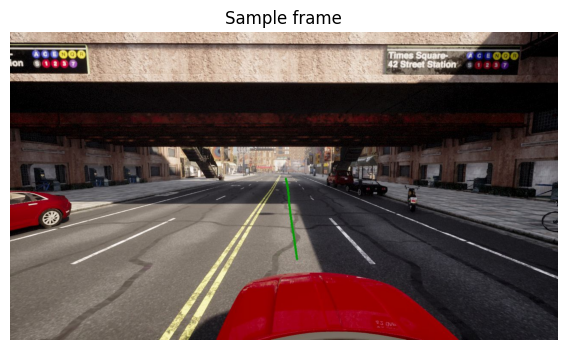

In [5]:
cam_id = int(topics_df.loc[topics_df["name"].str.contains("camera"), "id"].iloc[0])

cur = con.execute(
    "SELECT timestamp, data FROM messages "
    "WHERE topic_id = ? AND rowid BETWEEN 1 AND ?",
    (cam_id, MAX_ROWID)
)

SUBSAMPLE  = 3          # every 3rd frame → ~16k frames
JPEG_MAGIC = bytes([0xFF, 0xD8, 0xFF])

X_list, x_norms = [], []
sample_img = None
skipped = 0
i = 0

for ts, data in cur:
    i += 1
    if i % SUBSAMPLE != 0:
        continue

    jpeg_start = data.find(JPEG_MAGIC)
    if jpeg_start < 0:
        continue

    img = cv2.imdecode(np.frombuffer(data[jpeg_start:], dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        continue

    feat, x_norm = extract_features(img)
    if feat is None:
        skipped += 1
        continue

    X_list.append(feat)
    x_norms.append(x_norm)

    if sample_img is None:
        sample_img = img.copy()

    if len(X_list) % 1000 == 0:
        print(f"  {len(X_list)} frames processed...")

con.close()
print(f"\nProcessed: {len(X_list)} frames  |  skipped (no segment): {skipped}")

plt.figure(figsize=(8, 4))
plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
plt.title("Sample frame")
plt.axis("off")
plt.show()

## 6. Build labels from x_norm and inspect distribution

Feature matrix X: (16009, 4098)
Labels y:         (16009,)

Class distribution:
  LEFT      :  6616  (41.3%)  mean x_norm=-0.385
  STRAIGHT  :  2289  (14.3%)  mean x_norm=-0.005
  RIGHT     :  7104  (44.4%)  mean x_norm=+0.400


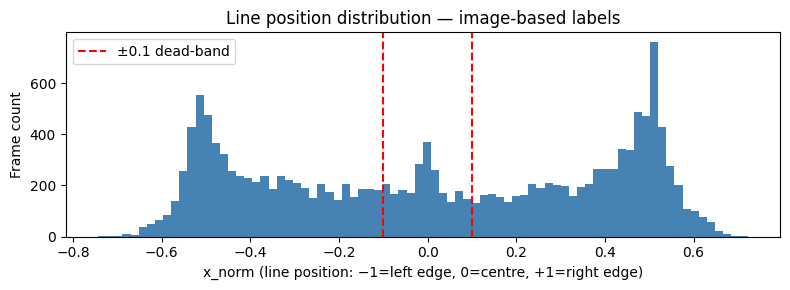

In [6]:
X        = np.array(X_list,  dtype=np.float32)
x_norms  = np.array(x_norms, dtype=np.float32)
y_labels = np.array([xnorm_to_label(x) for x in x_norms], dtype=np.int32)

print(f"Feature matrix X: {X.shape}")
print(f"Labels y:         {y_labels.shape}")
print()
print("Class distribution:")
for i, name in enumerate(CLASS_NAMES):
    mask = y_labels == i
    n    = mask.sum()
    mean_x = x_norms[mask].mean() if n > 0 else 0.0
    print(f"  {name:10s}: {n:5d}  ({100*n/len(y_labels):.1f}%)  mean x_norm={mean_x:+.3f}")

# Plot x_norm distribution with class boundaries
plt.figure(figsize=(8, 3))
plt.hist(x_norms, bins=80, color="steelblue", edgecolor="none")
plt.axvline(-DEAD_BAND, color="red",   linestyle="--", linewidth=1.5, label=f"±{DEAD_BAND} dead-band")
plt.axvline( DEAD_BAND, color="red",   linestyle="--", linewidth=1.5)
plt.xlabel("x_norm (line position: −1=left edge, 0=centre, +1=right edge)")
plt.ylabel("Frame count")
plt.title("Line position distribution — image-based labels")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Sanity check — mean x_norm per class

Because labels come directly from x_norm, the mean x_norm per class should be clearly separated:
- LEFT mean x_norm should be negative
- RIGHT mean x_norm should be positive
- STRAIGHT should be near zero

If this is not the case, adjust `DEAD_BAND` in cell 4.

Mean x_norm per class (should be clearly separated):
  LEFT      : mean=-0.385  min=-0.744  max=-0.103
  STRAIGHT  : mean=-0.005  min=-0.100  max=+0.100
  RIGHT     : mean=+0.400  min=+0.103  max=+0.722


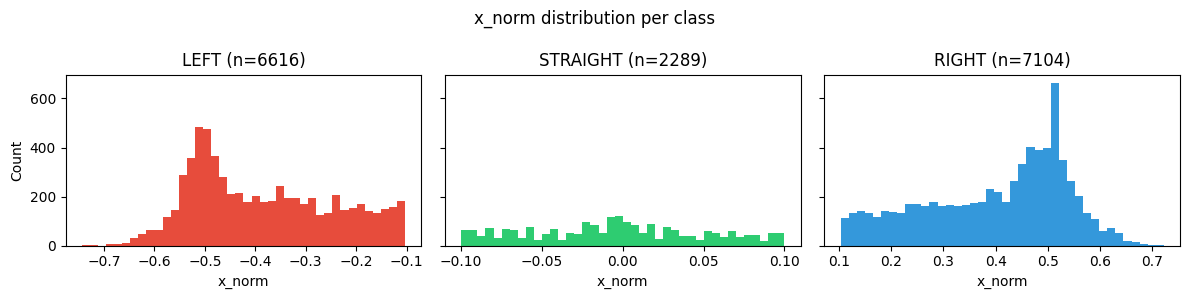

In [7]:
print("Mean x_norm per class (should be clearly separated):")
for i, name in enumerate(CLASS_NAMES):
    mask = y_labels == i
    vals = x_norms[mask]
    print(f"  {name:10s}: mean={vals.mean():+.3f}  min={vals.min():+.3f}  max={vals.max():+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
colors = ["#e74c3c", "#2ecc71", "#3498db"]
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    axes[i].hist(x_norms[y_labels == i], bins=40, color=color)
    axes[i].set_title(f"{name} (n={int((y_labels==i).sum())})")
    axes[i].set_xlabel("x_norm")
axes[0].set_ylabel("Count")
plt.suptitle("x_norm distribution per class")
plt.tight_layout()
plt.show()

## 8. Save to data/

In [8]:
np.save(str(DATA_DIR / "X_features.npy"), X)
np.save(str(DATA_DIR / "y_labels.npy"),   y_labels)

print("Saved:")
for f in sorted(DATA_DIR.glob("*.npy")):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")
print("\nDone. Run 02_train_svm.ipynb next.")

Saved:
  X_features.npy  (256269 KB)
  y_labels.npy  (62 KB)

Done. Run 02_train_svm.ipynb next.
